### Boilerplate code - llm initiation

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_openai import ChatOpenAI
import os
from dotenv import load_dotenv
from langchain_ollama import ChatOllama

load_dotenv("./env")

google_api_key = os.getenv("GOOGLE_API_KEY")
openai_api_key = os.getenv("OPENAI_API_KEY")

google_llm = ChatGoogleGenerativeAI(
    temperature=0, 
    model="gemini-2.5-flash", 
    api_key=google_api_key
)

openai_llm = ChatOpenAI(
    temperature=0, 
    model="gpt-5-mini", 
    api_key=openai_api_key
)

ollama_llm = ChatOllama(
    model="llama3.1:latest",
    temperature=0
)

# ollama_llm.invoke("I am from Mars").content

### Graph with Assistant & Tools

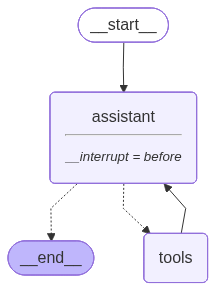

In [2]:
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import display, Image
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage


def add(a:int, b:int) -> int:
    "Adds two numbers - a and b"
    return a + b

def subtract(a:int, b:int) -> int:
    "Subtracts two numbers- a and b"
    return a - b

def multiply(a:int, b:int) -> int:
    "Multiplies two numbers - a and b"
    return a * b

def divide(a:int, b:int) -> int:
    "Divides two numbers - a and b"
    return a / b

tools = [add, subtract, multiply, divide]

llm_with_tools = openai_llm.bind_tools(tools)

memory = MemorySaver()


sys_msg = SystemMessage(content="You are a helpful assistant doing arithmetic operations from the given tools. Not anything else.")

def assistant(state: MessagesState) -> MessagesState:
    return {"messages": llm_with_tools.invoke([sys_msg] + state['messages'])}


builder = StateGraph(MessagesState)

builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))


builder.add_edge(START, "assistant")
builder.add_conditional_edges("assistant", tools_condition)
builder.add_edge("tools", "assistant")

graph = builder.compile(interrupt_before=["assistant"], checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))


### Stopping the graph execution with "interrupt_before"

In [ ]:
config = {"configurable": {"thread_id": "sdfasaa"}}

user_msg = {"messages": HumanMessage(content="Add 20 with 10")}


In [13]:
res = graph.invoke(user_msg, config=config)
print(res)

# for event in graph.stream(user_msg, config=config, stream_mode="values"):
#     print(event)

{'messages': [HumanMessage(content='Add 20 with 10', additional_kwargs={}, response_metadata={}, id='c74dcc2a-6229-4593-8350-782c9a4fca70')]}


In [14]:
for msg in res.get('messages'):
    msg.pretty_print()

================================ Human Message =================================

Add 20 with 10


In [17]:
current_state = graph.get_state(config)
current_state.values

{'messages': [HumanMessage(content='Add 20 with 10', additional_kwargs={}, response_metadata={}, id='c74dcc2a-6229-4593-8350-782c9a4fca70'),
  HumanMessage(content='No. Add 20 with 10, then subtract the result with 5', additional_kwargs={}, response_metadata={}, id='b093ee35-4ffd-4368-875a-055449f4ee3f')]}

### Updating the state

In [16]:
from langchain_core.messages import HumanMessage

new_config = graph.update_state(config, {"messages": HumanMessage(content="No. Add 20 with 10, then subtract the result with 5")})

new_config

{'configurable': {'thread_id': 'asd',
  'checkpoint_ns': '',
  'checkpoint_id': '1f139a90-76d9-6b7e-8003-f8a3f0391725'}}

In [59]:
for event in graph.stream(None, config=config, stream_mode="values"):
    event['messages']

In [ ]:
while graph.get_state(config).next:
    state = graph.get_state(config)
    print(f"\nPaused. Next node: {state.next}")
    print(f"Last message: {state.values['messages'][-1]}")
    
    user_approval = input("\nApprove? (yes/no): ")
    if user_approval.lower() == "yes":
        for event in graph.stream(None, config=config, stream_mode="values"):
            event['messages'][-1].pretty_print()
    else:
        break



⏸ Paused. Next node: ('assistant',)
Last message: content='30' name='add' id='ebb11865-4a31-467b-a691-d6c34796b059' tool_call_id='call_whupK6SUUcQLxs54pQet65T2'
================================= Tool Message =================================
Name: add

30
================================== Ai Message ==================================
Tool Calls:
  subtract (call_M6oKMQYOb4QW0JpTC8G6BcCE)
 Call ID: call_M6oKMQYOb4QW0JpTC8G6BcCE
  Args:
    a: 30
    b: 5
================================= Tool Message =================================
Name: subtract

25

⏸ Paused. Next node: ('assistant',)
Last message: content='25' name='subtract' id='ec9af990-a249-43c9-bde4-e76769402cc1' tool_call_id='call_M6oKMQYOb4QW0JpTC8G6BcCE'
================================= Tool Message =================================
Name: subtract

25
================================== Ai Message ==================================

25


##### Clearing messages in the state

In [47]:
from langchain_core.messages import RemoveMessage

messages = graph.get_state(config).values['messages']

messages_for_deletion = [RemoveMessage(id=msg.id) for msg in messages]

graph.update_state(config, {"messages": messages_for_deletion}, as_node="tools")

{'configurable': {'thread_id': 'kakak',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1399f2-6d25-66da-8004-d388e7dfc289'}}

## For Youtube Explanation

In [4]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_openai import ChatOpenAI
import os
from dotenv import load_dotenv
from langchain_ollama import ChatOllama

load_dotenv("./env")

google_api_key = os.getenv("GOOGLE_API_KEY")
openai_api_key = os.getenv("OPENAI_API_KEY")

google_llm = ChatGoogleGenerativeAI(
    temperature=0, 
    model="gemini-2.5-flash", 
    api_key=google_api_key,
    max_tokens=200
)

openai_llm = ChatOpenAI(
    temperature=0, 
    model="gpt-5-mini", 
    api_key=openai_api_key
)

# ollama_llm = ChatOllama(
#     model="llama3.1:latest",
#     temperature=0
# )

# openai_llm.invoke("what is 2+2").content

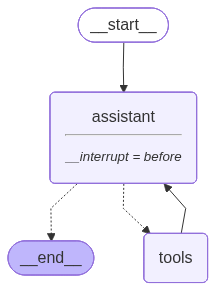

In [5]:
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import display, Image
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage


def add(a:int, b:int) -> int:
    "Adds two numbers - a and b"
    return a + b

def subtract(a:int, b:int) -> int:
    "Subtracts two numbers- a and b"
    return a - b

def multiply(a:int, b:int) -> int:
    "Multiplies two numbers - a and b"
    return a * b

def divide(a:int, b:int) -> int:
    "Divides two numbers - a and b"
    return a / b

tools = [add, subtract, multiply, divide]

llm_with_tools = openai_llm.bind_tools(tools)

memory = MemorySaver()


sys_msg = SystemMessage(content="You are a helpful assistant doing arithmetic operations from the given tools. Not anything else.")

def assistant(state: MessagesState) -> MessagesState:
    return {"messages": llm_with_tools.invoke([sys_msg] + state['messages'])}


builder = StateGraph(MessagesState)

builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))


builder.add_edge(START, "assistant")
builder.add_conditional_edges("assistant", tools_condition)
builder.add_edge("tools", "assistant")

graph = builder.compile(interrupt_before=["assistant"], checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [48]:
config = {"configurable": {"thread_id": "lflflfskosjd"}}

user_msg = {"messages": HumanMessage(content="Add 20 with 10")}

In [49]:
res = graph.invoke(user_msg, config=config)
print(res)

# for event in graph.stream(user_msg, config=config, stream_mode="values"):
#     print(event)

{'messages': [HumanMessage(content='Add 20 with 10', additional_kwargs={}, response_metadata={}, id='0aa60b8d-ed25-48b9-a2a1-788fe3720ad6')]}


In [50]:
for msg in res.get('messages'):
    msg.pretty_print()

================================ Human Message =================================

Add 20 with 10


In [53]:
current_state = graph.get_state(config)
current_state.values

{'messages': [HumanMessage(content='Add 20 with 10', additional_kwargs={}, response_metadata={}, id='0aa60b8d-ed25-48b9-a2a1-788fe3720ad6'),
  HumanMessage(content='No. Add 20 with 10, then subtract the result with 5', additional_kwargs={}, response_metadata={}, id='3c3b30d6-c0a3-40db-889e-bc389e76a6c5')]}

In [52]:
from langchain_core.messages import HumanMessage

new_config = graph.update_state(config, {"messages": HumanMessage(content="No. Add 20 with 10, then subtract the result with 5")})

new_config

{'configurable': {'thread_id': 'lflflfskosjd',
  'checkpoint_ns': '',
  'checkpoint_id': '1f13bd12-e17c-60f4-8001-5fb53f23a027'}}

In [54]:
while graph.get_state(config).next:
    state = graph.get_state(config)
    print(f"\nPaused. Next node: {state.next}")
    print(f"Last message: {state.values['messages'][-1]}")
    
    user_approval = input("\nApprove? (yes/no): ")
    if user_approval.lower() == "yes":
        for event in graph.stream(None, config=config, stream_mode="values"):
            event['messages'][-1].pretty_print()
    else:
        break


Paused. Next node: ('assistant',)
Last message: content='No. Add 20 with 10, then subtract the result with 5' additional_kwargs={} response_metadata={} id='3c3b30d6-c0a3-40db-889e-bc389e76a6c5'
================================ Human Message =================================

No. Add 20 with 10, then subtract the result with 5
================================== Ai Message ==================================
Tool Calls:
  add (call_rH0y3myWTuxXUThfAxNd2Oh9)
 Call ID: call_rH0y3myWTuxXUThfAxNd2Oh9
  Args:
    a: 20
    b: 10
================================= Tool Message =================================
Name: add

30

Paused. Next node: ('assistant',)
Last message: content='30' name='add' id='6dda2d5c-c3cb-4f83-a632-26ac040b492f' tool_call_id='call_rH0y3myWTuxXUThfAxNd2Oh9'
================================= Tool Message =================================
Name: add

30
================================== Ai Message ==================================
Tool Calls:
  subtract (call_QnK5F3MRxqIL